# Official Mamba-UNet baseline on GLySAC — RUN-ALL V2.1

This is a separate baseline using the published Mamba-UNet implementation by
Wang et al. Its native VSSM encoder, bottleneck, skip connections, Mamba decoder,
and final patch expansion are retained. Only the original one-task 1x1 output
convolution is replaced by lightweight `np`, `hv`, and `tp` 1x1 heads. The
GLySAC split, data pipeline, targets, losses, watershed, metrics, seed, and
training schedule match the MambaVision-SMILE experiment.

Outputs include Dice, IoU/Jaccard, pixel accuracy/precision/recall/F1,
class-wise pixel metrics, AJI/AJI+, detection/classification metrics, and
explicit binary and type-aware multiclass DQ/SQ/PQ. Results and predictions
are written to `/kaggle/working/mamba_unet_glysac`.

**Before running:** attach GLySAC as a Kaggle Input, select a GPU accelerator,
and enable Internet. The notebook pins the official Mamba-UNet repository and
downloads the exact VMamba-T epoch-292 ImageNet-1K checkpoint used by its config.

Compatibility fix: the official Mamba-UNet/fvcore modules are imported before
SMILE post-processing. SMILE's legacy post-processing module replaces
`warnings.warn` globally; the original warning function is restored immediately
after that import so current PyTorch/TorchScript can initialize reliably.
V2.1 also repairs the pinned repository's incomplete strict-YACS VSSM schema
before merging its official `vmamba_tiny.yaml`.

In [1]:
# ----------------------------- USER CONFIG ----------------------------------
from pathlib import Path

NOTEBOOK_BUILD = "MAMBA_UNET_GLYSAC_RUN_ALL_V2.1_2026-09-18"
print("RUNNING NOTEBOOK BUILD:", NOTEBOOK_BUILD)

CFG = {
    # Dataset root. Leave None to search /kaggle/input for a GLySAC-like layout.
    "DATA_ROOT": "/kaggle/input/datasets/gourangamaitymca/gastric-lymphocyte-seg-classificationglysac/glysac_dataset_seg_classification/glysac_dataset",
    # Optional CSV with columns `stem,split` (split = train/val/test). This is the
    # safest option if your copy is flat or uses non-obvious directory names.
    "SPLIT_CSV": None,
    # "auto", "original_10_class", or "already_merged_3_class".
    "TYPE_ENCODING": "auto",
    "STRICT_OFFICIAL_SPLIT": True,  # expect 34 train and 25 test GLySAC tiles
    "REPO_DIR": "/kaggle/working/smile",
    "REPO_URL": "https://github.com/panxipeng/nuclear_segandcls.git",
    "MAMBA_UNET_REPO_DIR": "/kaggle/working/Mamba-UNet",
    "MAMBA_UNET_REPO_URL": "https://github.com/ziyangwang007/Mamba-UNet.git",
    # Original public Mamba-UNet implementation commit (6 Feb 2024).
    "MAMBA_UNET_COMMIT": "2eeec299581934e05b2af0322cc3107e2605867a",
    "PRETRAIN_URL": "https://github.com/MzeroMiko/VMamba/releases/download/%23v0cls/vssmtiny_dp01_ckpt_epoch_292.pth",
    "PRETRAIN_SHA256": "dbc0cc4f5ec0e45db5fba7c939d2c7d9b617e891ac10766912a8d604c37c5e47",
    "PRETRAIN_DATASET": "ImageNet-1K classification, 224x224, VMamba-T epoch 292",
    "OUTPUT_DIR": "/kaggle/working/mamba_unet_glysac",
    "RESUME_CHECKPOINT": None,
    "SEED": 42,
    "PATCH_SIZE": 256,
    "INFER_OVERLAP": 64,
    "BATCH_SIZE": 2,          # unchanged from the SMILE notebook
    "INFER_BATCH_SIZE": 2,
    "PATCHES_PER_TILE": 12,
    "EPOCHS": 200,            # matches the repository's full training phase
    "LR": 1e-4,
    "PRETRAINED_LR": 1e-5,    # entire official Mamba-UNet core
    "WEIGHT_DECAY": 0.0,
    "NUM_WORKERS": 2,
    # GLySAC has no supplied validation directory. Hold out the same deterministic
    # seed-42 tile subset from the official 34 training images (29 train / 5 val).
    "VAL_FRACTION": 0.15,
    "EVAL_EVERY": 5,
    "MAGNIFICATION": 40,     # GLySAC/Sonnet evaluation uses radius 12 at 40x
    "MATCH_IOU": 0.5,
    "MIN_FOREGROUND_FRACTION": 0.01,
    "EARLY_STOPPING_PATIENCE": 4,  # counted in validation events; None disables
    # Keep identical to the comparison notebook.
    "AMP": False,
    "DETERMINISTIC": True,
    "SMOKE_TEST": False,      # 1 epoch, 2 train tiles, 1 val/test tile
}

RUNNING NOTEBOOK BUILD: MAMBA_UNET_GLYSAC_RUN_ALL_V2.1_2026-09-18


## 1. Environment and repository

This installs only small compatibility dependencies. It deliberately does not
install the repository's legacy PyTorch 1.7 environment, which is incompatible
with current Kaggle CUDA images.

In [2]:
import os, sys, subprocess, importlib.util, json, urllib.request, hashlib

def pip_install_if_missing(module, package):
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

# Dependencies required by the pinned official Mamba-UNet source. The CUDA
# selective-scan wheel is selected separately to match the live Kaggle runtime.
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "timm==1.0.15", "einops==0.8.1", "yacs>=0.1.8", "fvcore>=0.1.5"], check=True)

for module, package in [
    ("cv2", "opencv-python-headless>=4.8"),
    ("skimage", "scikit-image>=0.20"), ("scipy", "scipy>=1.9"),
    ("pandas", "pandas>=1.5"), ("tqdm", "tqdm>=4.64"),
]:
    pip_install_if_missing(module, package)

def ensure_matching_mamba_kernel():
    try:
        from mamba_ssm.ops.selective_scan_interface import selective_scan_fn
        print("Mamba selective-scan kernel already imports correctly.")
        return selective_scan_fn
    except Exception as first_error:
        print("Installing a Mamba wheel matched to this Kaggle runtime:", repr(first_error))
    import torch
    version = "2.3.2.post1"
    py_tag = f"cp{sys.version_info.major}{sys.version_info.minor}"
    torch_tag = ".".join(torch.__version__.split("+")[0].split(".")[:2])
    if not torch.version.cuda:
        raise RuntimeError("Mamba-UNet training requires a CUDA Kaggle accelerator.")
    cuda_tag = "cu12" if int(torch.version.cuda.split(".")[0]) >= 12 else "cu11"
    abi = str(bool(torch._C._GLIBCXX_USE_CXX11_ABI)).upper()
    wanted = f"mamba_ssm-{version}+{cuda_tag}torch{torch_tag}cxx11abi{abi}-{py_tag}-{py_tag}-linux_x86_64.whl"
    api = f"https://api.github.com/repos/state-spaces/mamba/releases/tags/v{version}"
    with urllib.request.urlopen(api, timeout=30) as response:
        assets = json.load(response)["assets"]
    urls = {a["name"]: a["browser_download_url"] for a in assets}
    if wanted not in urls:
        available = sorted(n for n in urls if py_tag in n and cuda_tag in n)
        raise RuntimeError(
            f"No official Mamba wheel matches {wanted}. Matching Python/CUDA assets: {available[:12]}"
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps",
                    "--force-reinstall", urls[wanted]], check=True)
    for name in list(sys.modules):
        if name == "mamba_ssm" or name.startswith("mamba_ssm."): del sys.modules[name]
    importlib.invalidate_caches()
    from mamba_ssm.ops.selective_scan_interface import selective_scan_fn
    print("Installed:", wanted)
    return selective_scan_fn

_selective_scan_preflight = ensure_matching_mamba_kernel()

repo_dir = Path(CFG["REPO_DIR"])
if not (repo_dir / "models/smile/net_desc_smile.py").exists():
    if Path("/kaggle/input").exists() and not os.environ.get("KAGGLE_KERNEL_RUN_TYPE"):
        print("Not running in a Kaggle kernel; cloning into the configured working path.")
    repo_dir.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(["git", "clone", "--depth", "1", CFG["REPO_URL"], str(repo_dir)], check=True)

# SMILE's legacy post-processor globally replaces `warnings.warn` with a
# variadic no-op. Current PyTorch/fvcore may attempt to TorchScript a call path
# that reaches it and then abort before model construction. Remove only that
# process-global side effect from the cloned copy; the watershed/process
# implementation itself is unchanged. Doing this here makes all later import
# orders safe, including a completely unattended Kaggle "Run All".
smile_post_proc_path = repo_dir / "models/smile/post_proc.py"
smile_post_proc_source = smile_post_proc_path.read_text()
legacy_warning_patch = "warnings.warn = noop"
if legacy_warning_patch in smile_post_proc_source:
    smile_post_proc_source = smile_post_proc_source.replace(
        legacy_warning_patch,
        "# RUN-ALL compatibility: do not replace warnings.warn process-wide",
    )
    smile_post_proc_path.write_text(smile_post_proc_source)
remaining_source = smile_post_proc_path.read_text()
assert legacy_warning_patch not in remaining_source
print("SMILE warning monkey-patch neutralized: PASS")
sys.path.insert(0, str(repo_dir))
print("SMILE repository:", repo_dir)

mamba_repo = Path(CFG["MAMBA_UNET_REPO_DIR"])
if not (mamba_repo / ".git").exists():
    mamba_repo.mkdir(parents=True, exist_ok=True)
    subprocess.run(["git", "init", "-q", str(mamba_repo)], check=True)
    subprocess.run(["git", "-C", str(mamba_repo), "remote", "add", "origin",
                    CFG["MAMBA_UNET_REPO_URL"]], check=True)
subprocess.run(["git", "-C", str(mamba_repo), "fetch", "-q", "--depth", "1",
                "origin", CFG["MAMBA_UNET_COMMIT"]], check=True)
subprocess.run(["git", "-C", str(mamba_repo), "checkout", "-q", "--detach",
                CFG["MAMBA_UNET_COMMIT"]], check=True)
actual_commit = subprocess.check_output(
    ["git", "-C", str(mamba_repo), "rev-parse", "HEAD"], text=True
).strip()
assert actual_commit == CFG["MAMBA_UNET_COMMIT"]
sys.path.insert(0, str(mamba_repo / "code"))
print("Official Mamba-UNet repository:", mamba_repo, "| commit:", actual_commit)

pretrain_path = mamba_repo / "code/pretrained_ckpt/vmamba_tiny_e292.pth"
pretrain_path.parent.mkdir(parents=True, exist_ok=True)
def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(8 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()

if not pretrain_path.exists() or sha256_file(pretrain_path) != CFG["PRETRAIN_SHA256"]:
    download_path = pretrain_path.with_suffix(".download")
    urllib.request.urlretrieve(CFG["PRETRAIN_URL"], download_path)
    actual_sha = sha256_file(download_path)
    if actual_sha != CFG["PRETRAIN_SHA256"]:
        raise RuntimeError(f"Pretrained checkpoint SHA-256 mismatch: {actual_sha}")
    os.replace(download_path, pretrain_path)
print("Pretrained checkpoint:", CFG["PRETRAIN_URL"])
print("Pretraining dataset:", CFG["PRETRAIN_DATASET"])
print("Checkpoint SHA-256:", sha256_file(pretrain_path))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.0/129.0 kB 9.5 MB/s eta 0:00:00
Installing a Mamba wheel matched to this Kaggle runtime: ModuleNotFoundError("No module named 'mamba_ssm'")
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 4.9 MB/s eta 0:00:00
Installed: mamba_ssm-2.3.2.post1+cu12torch2.10cxx11abiTRUE-cp312-cp312-linux_x86_64.whl


Cloning into '/kaggle/working/smile'...


SMILE warning monkey-patch neutralized: PASS
SMILE repository: /kaggle/working/smile
Official Mamba-UNet repository: /kaggle/working/Mamba-UNet | commit: 2eeec299581934e05b2af0322cc3107e2605867a
Pretrained checkpoint: https://github.com/MzeroMiko/VMamba/releases/download/%23v0cls/vssmtiny_dp01_ckpt_epoch_292.pth
Pretraining dataset: ImageNet-1K classification, 224x224, VMamba-T epoch 292
Checkpoint SHA-256: dbc0cc4f5ec0e45db5fba7c939d2c7d9b617e891ac10766912a8d604c37c5e47


In [3]:
import random, re, warnings, shutil, time, importlib
from collections import defaultdict, OrderedDict
from dataclasses import dataclass

import cv2
import numpy as np
import pandas as pd
import scipy.io as sio
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import display
from scipy.ndimage import center_of_mass
from scipy.optimize import linear_sum_assignment
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
# IMPORTANT: keep the Mamba-UNet/fvcore imports above the SMILE post-processing
# import. The legacy SMILE module assigns `warnings.warn = noop`, and importing
# fvcore afterwards makes TorchScript try to compile that variadic noop function.
# Reloading also makes this cell safe to rerun after an earlier failed attempt
# left the global monkey-patch active in the current Kaggle kernel.
warnings = importlib.reload(warnings)
_stdlib_warnings_warn = warnings.warn
from config import _C as MAMBA_DEFAULT_CONFIG
from networks.vision_mamba import MambaUnet

# Restore the genuine stdlib function immediately so the monkey-patch cannot leak
# into PyTorch, fvcore, or the rest of this notebook.
try:
    from models.smile.post_proc import process as smile_post_process
finally:
    warnings.warn = _stdlib_warnings_warn
assert warnings.warn is _stdlib_warnings_warn
print("Import compatibility preflight: PASS (Mamba-UNet loaded; warnings.warn restored)")

warnings.filterwarnings("ignore", category=FutureWarning)
OUT = Path(CFG["OUTPUT_DIR"])
OUT.mkdir(parents=True, exist_ok=True)

seed = int(CFG["SEED"])
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.benchmark = not CFG["DETERMINISTIC"]
torch.use_deterministic_algorithms(bool(CFG["DETERMINISTIC"]), warn_only=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "| torch:", torch.__version__)
if DEVICE.type != "cuda":
    print("WARNING: training on CPU is only suitable for a smoke test.")

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Import compatibility preflight: PASS (Mamba-UNet loaded; warnings.warn restored)
Device: cuda | torch: 2.10.0+cu128


## 2. Find and validate GLySAC

Supported annotations are MATLAB files containing `inst_map` and `type_map`.
Image formats may be PNG, TIFF/TIF, BMP, or JPEG. Automatic split detection
requires `train`, `val`, or `test` in a parent directory or filename. If that
is not true for your Kaggle copy, provide `SPLIT_CSV`; the notebook will not
invent a test split because that would make a SOTA comparison invalid.

In [4]:
IMAGE_EXTS = {".png", ".tif", ".tiff", ".bmp", ".jpg", ".jpeg"}
CLASS_NAMES = {0: "background", 1: "other", 2: "lymphocyte", 3: "epithelial"}

@dataclass(frozen=True)
class Record:
    stem: str
    image: Path
    label: Path
    split: str

def mat_has_maps(path):
    try:
        names = {x[0] for x in sio.whosmat(path)}
        return {"inst_map", "type_map"}.issubset(names)
    except Exception:
        return False

def infer_split(path):
    parts = [p.lower() for p in path.parts[-5:]]
    # Handles names such as Test(split), Labels_Test and train-images.
    if any(re.search(r"(^|[^a-z])test", p) for p in parts): return "test"
    if any(re.search(r"(^|[^a-z])val(id|idation)?", p) for p in parts): return "val"
    if any(re.search(r"(^|[^a-z])train", p) for p in parts): return "train"
    return ""

def choose_data_root():
    if CFG["DATA_ROOT"]:
        root = Path(CFG["DATA_ROOT"])
        if root.exists(): return root
        # Kaggle sometimes mounts the same dataset without /datasets/<owner>.
        base = Path("/kaggle/input")
        matches = list(base.glob("**/glysac_dataset_seg_classification/glysac_dataset")) if base.exists() else []
        if len(matches) == 1:
            print(f"Configured path was not mounted verbatim; resolved GLySAC to {matches[0]}")
            return matches[0]
        raise FileNotFoundError(f"DATA_ROOT does not exist: {root}; fallback matches: {matches}")
    base = Path("/kaggle/input") if Path("/kaggle/input").exists() else Path.cwd()
    scored = []
    candidates = [p for p in base.glob("*") if p.is_dir()] or [base]
    for d in candidates:
        mats = sum(1 for p in d.rglob("*.mat") if mat_has_maps(p))
        if mats: scored.append(("glysac" in d.name.lower(), mats, d))
    if not scored:
        raise FileNotFoundError("No .mat files with inst_map + type_map found. Set CFG['DATA_ROOT'].")
    scored.sort(key=lambda x: (x[0], x[1]), reverse=True)
    print("Auto-selected data root from candidates:", scored[:5])
    return scored[0][2]

def discover_records(root):
    images = defaultdict(list)
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            images[p.stem.lower()].append(p)
    split_lookup = {}
    if CFG["SPLIT_CSV"]:
        frame = pd.read_csv(CFG["SPLIT_CSV"])
        if not {"stem", "split"}.issubset(frame.columns):
            raise ValueError("SPLIT_CSV must contain columns: stem, split")
        split_lookup = dict(zip(frame.stem.astype(str).str.lower(), frame.split.astype(str).str.lower()))
    records, problems = [], []
    for label in sorted(root.rglob("*.mat")):
        if not mat_has_maps(label): continue
        candidates = images.get(label.stem.lower(), [])
        if not candidates:
            problems.append(f"No image for {label}"); continue
        # Prefer the image nearest to its label in the directory tree.
        image = max(candidates, key=lambda p: len(os.path.commonpath([p, label]).split(os.sep)))
        split = split_lookup.get(label.stem.lower()) or infer_split(label) or infer_split(image)
        records.append(Record(label.stem, image, label, split))
    if problems:
        print("Unmatched files (first 10):", *problems[:10], sep="\n  ")
    if not records: raise RuntimeError("No matched GLySAC image/annotation pairs found.")
    unknown = [r for r in records if not r.split]
    if unknown:
        example = "\n".join(f"  {r.image} | {r.label}" for r in unknown[:8])
        raise RuntimeError(
            f"Cannot prove the split for {len(unknown)} pair(s). Supply CFG['SPLIT_CSV'] "
            f"with stem,split columns. Examples:\n{example}"
        )
    bad = sorted({r.split for r in records} - {"train", "val", "test"})
    if bad: raise ValueError(f"Unknown split labels: {bad}")
    return records

DATA_ROOT = choose_data_root()
records = discover_records(DATA_ROOT)
manifest = pd.DataFrame([{"stem": r.stem, "split": r.split,
                          "image": str(r.image), "label": str(r.label)} for r in records])
print(manifest.groupby("split").size())
display(manifest.head())

train_records = [r for r in records if r.split == "train"]
val_records = [r for r in records if r.split == "val"]
test_records = [r for r in records if r.split == "test"]
if not train_records or not test_records:
    raise RuntimeError("Both official train and test records are required.")
if CFG["STRICT_OFFICIAL_SPLIT"] and not val_records and (len(train_records), len(test_records)) != (34, 25):
    raise RuntimeError(
        f"Expected the official 34/25 GLySAC split, found {len(train_records)}/{len(test_records)}. "
        "Check DATA_ROOT rather than disabling this guard for a SOTA comparison."
    )
if not val_records and float(CFG["VAL_FRACTION"]) > 0:
    # Reproducible tile-level holdout from official training data only.
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(train_records))
    n_val = max(1, round(len(train_records) * float(CFG["VAL_FRACTION"])))
    val_ids = set(order[:n_val].tolist())
    val_records = [r for i, r in enumerate(train_records) if i in val_ids]
    train_records = [r for i, r in enumerate(train_records) if i not in val_ids]
    print(f"Created a reproducible validation holdout: {len(train_records)} train / {len(val_records)} val")
elif not val_records:
    print("No validation holdout: using fixed-epoch training on all official training tiles.")

if CFG["SMOKE_TEST"]:
    CFG.update(EPOCHS=1, PATCHES_PER_TILE=2, EVAL_EVERY=1, EARLY_STOPPING_PATIENCE=None)
    train_records, test_records = train_records[:2], test_records[:1]
    if not val_records:
        val_records, train_records = train_records[-1:], train_records[:1]
    else:
        val_records = val_records[:1]

effective_split = []
for split, rows in [("train", train_records), ("val", val_records), ("test", test_records)]:
    effective_split.extend({"stem": r.stem, "split": split,
                            "image": str(r.image), "label": str(r.label)} for r in rows)
split_frame=pd.DataFrame(effective_split)
split_frame.to_csv(OUT / "split_manifest.csv", index=False)
split_identity="\n".join(f"{x.split}:{x.stem}" for x in split_frame.itertuples(index=False))
split_sha256=hashlib.sha256(split_identity.encode()).hexdigest()
assert not ({r.stem for r in train_records} & {r.stem for r in test_records})
print("Effective split:", {"train": len(train_records), "val": len(val_records), "test": len(test_records)})
print("Split identity SHA-256 (split:stem):",split_sha256)

split
test     25
train    34
dtype: int64


,stem,split,image,label
0,AGC1_tumor_11,test,/kaggle/input/datasets/gourangamaitymca/gastri...,/kaggle/input/datasets/gourangamaitymca/gastri...
1,AGC1_tumor_2,test,/kaggle/input/datasets/gourangamaitymca/gastri...,/kaggle/input/datasets/gourangamaitymca/gastri...
2,AGC1_tumor_4,test,/kaggle/input/datasets/gourangamaitymca/gastri...,/kaggle/input/datasets/gourangamaitymca/gastri...
3,DB-0001_normal_1,test,/kaggle/input/datasets/gourangamaitymca/gastri...,/kaggle/input/datasets/gourangamaitymca/gastri...
4,DB-0001_tumor_2,test,/kaggle/input/datasets/gourangamaitymca/gastri...,/kaggle/input/datasets/gourangamaitymca/gastri...


Created a reproducible validation holdout: 29 train / 5 val
Effective split: {'train': 29, 'val': 5, 'test': 25}
Split identity SHA-256 (split:stem): edf16c64430947fcc94df06147d0798a373cae1f9fa2b3b4da16125ed5098d2d


Checking label encoding:   0%|          | 0/59 [00:00<?, ?it/s]

Detected type encoding: original_10_class | IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
AGC1_tumor_1 (1000, 1000, 3) instances= 969 types= {np.uint8(0): np.int64(722672), np.uint8(1): np.int64(121741), np.uint8(2): np.int64(155587)}


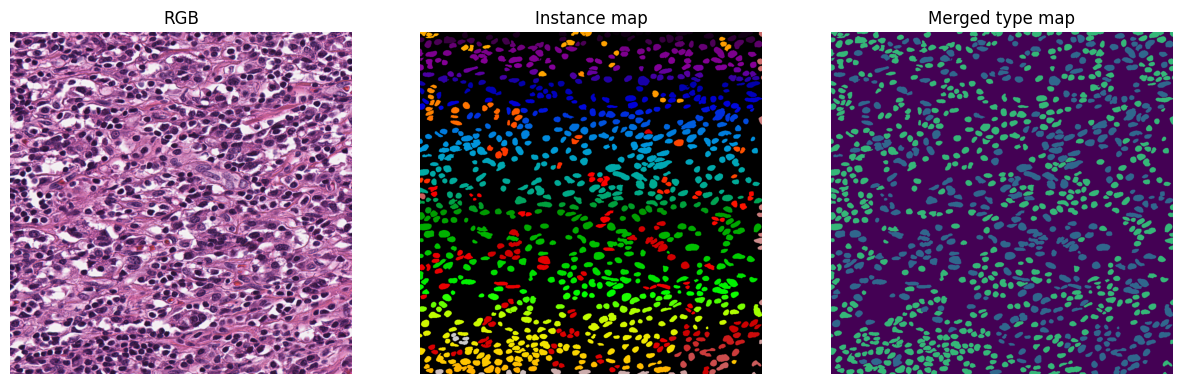

In [5]:
def read_rgb(path):
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None: raise OSError(f"Cannot read image: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def find_type_encoding(rows):
    ids = set()
    for r in tqdm(rows, desc="Checking label encoding"):
        ids.update(np.unique(sio.loadmat(r.label, variable_names=["type_map"])["type_map"]).tolist())
    unknown = ids - set(range(11))
    if unknown: raise ValueError(f"Unexpected GLySAC type IDs: {sorted(unknown)}")
    allowed = {"auto", "original_10_class", "already_merged_3_class"}
    if CFG["TYPE_ENCODING"] not in allowed: raise ValueError(f"TYPE_ENCODING must be one of {allowed}")
    encoding = CFG["TYPE_ENCODING"]
    if encoding == "auto":
        encoding = "original_10_class" if any(x > 3 for x in ids) else "already_merged_3_class"
    print("Detected type encoding:", encoding, "| IDs:", sorted(ids))
    return encoding

TYPE_ENCODING = find_type_encoding(records)

def merge_glysac_types(type_map):
    t = np.asarray(type_map, dtype=np.int32)
    if TYPE_ENCODING == "already_merged_3_class": return t.astype(np.uint8)
    out = np.zeros_like(t, dtype=np.uint8)
    for old in (1, 2, 9, 10): out[t == old] = 1       # Other
    for old in (4, 5, 6, 7): out[t == old] = 2        # Lymphocyte
    for old in (3, 8): out[t == old] = 3               # Epithelial
    return out

def read_annotation(path):
    ann = sio.loadmat(path, variable_names=["inst_map", "type_map"])
    inst = np.asarray(ann["inst_map"], dtype=np.int32).squeeze()
    typ = merge_glysac_types(np.asarray(ann["type_map"]).squeeze())
    if inst.shape != typ.shape: raise ValueError(f"Shape mismatch in {path}: {inst.shape} vs {typ.shape}")
    typ = typ.copy(); typ[inst == 0] = 0
    return inst, typ

def inspect_record(record):
    image = read_rgb(record.image); inst, typ = read_annotation(record.label)
    if image.shape[:2] != inst.shape: raise ValueError(f"Image/label mismatch for {record.stem}")
    print(record.stem, image.shape, "instances=", len(np.unique(inst))-1,
          "types=", dict(zip(*np.unique(typ, return_counts=True))))
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(image); ax[0].set_title("RGB")
    ax[1].imshow(inst, cmap="nipy_spectral"); ax[1].set_title("Instance map")
    ax[2].imshow(typ, vmin=0, vmax=3, cmap="viridis"); ax[2].set_title("Merged type map")
    for a in ax: a.axis("off")
    plt.show()

inspect_record(train_records[0])

## 3. Training patches, targets, and model

In [6]:
def bbox(mask):
    rows, cols = np.where(mask)
    if not len(rows): return None
    return [rows.min(), rows.max() + 1, cols.min(), cols.max() + 1]

def make_hv_map(inst_map):
    x_map = np.zeros(inst_map.shape, np.float32)
    y_map = np.zeros(inst_map.shape, np.float32)
    for inst_id in np.unique(inst_map):
        if inst_id == 0: continue
        mask_full = inst_map == inst_id
        box = bbox(mask_full)
        if box is None: continue
        r0, r1, c0, c1 = box
        r0, c0 = max(0, r0 - 2), max(0, c0 - 2)
        r1, c1 = min(inst_map.shape[0], r1 + 2), min(inst_map.shape[1], c1 + 2)
        mask = mask_full[r0:r1, c0:c1]
        if min(mask.shape) < 2: continue
        cy, cx = center_of_mass(mask)
        yy, xx = np.meshgrid(np.arange(mask.shape[0]) - round(cy),
                             np.arange(mask.shape[1]) - round(cx), indexing="ij")
        xx, yy = xx.astype(np.float32), yy.astype(np.float32)
        xx[~mask] = 0; yy[~mask] = 0
        neg = xx < 0; pos = xx > 0
        if neg.any(): xx[neg] /= -xx[neg].min()
        if pos.any(): xx[pos] /= xx[pos].max()
        neg = yy < 0; pos = yy > 0
        if neg.any(): yy[neg] /= -yy[neg].min()
        if pos.any(): yy[pos] /= yy[pos].max()
        x_map[r0:r1, c0:c1][mask] = xx[mask]
        y_map[r0:r1, c0:c1][mask] = yy[mask]
    return np.stack([x_map, y_map])

def pad_to_minimum(image, inst, typ, size):
    ph, pw = max(0, size-image.shape[0]), max(0, size-image.shape[1])
    if ph or pw:
        image = np.pad(image, ((0, ph), (0, pw), (0, 0)), mode="reflect")
        inst = np.pad(inst, ((0, ph), (0, pw)), mode="constant")
        typ = np.pad(typ, ((0, ph), (0, pw)), mode="constant")
    return image, inst, typ

class RandomPatchDataset(Dataset):
    def __init__(self, records, patch_size, patches_per_tile, seed, augment=True):
        self.records, self.size = list(records), int(patch_size)
        self.length = len(records) * int(patches_per_tile)
        self.seed, self.augment = int(seed), bool(augment)
        self.rng = np.random.default_rng(seed)
        # GLySAC is small enough to cache; this avoids repeatedly decoding MAT files.
        self.tiles = []
        for r in tqdm(self.records, desc="Caching train tiles"):
            im = read_rgb(r.image); ins, typ = read_annotation(r.label)
            im, ins, typ = pad_to_minimum(im, ins, typ, self.size)
            self.tiles.append((im, ins, typ, r.stem))

    def __len__(self): return self.length

    def __getitem__(self, index):
        image, inst, typ, stem = self.tiles[index % len(self.tiles)]
        h, w = inst.shape
        # Validation coordinates are fixed across epochs; training retains the
        # original stateful random patch sampler.
        rng = self.rng if self.augment else np.random.default_rng(self.seed + index)
        for _ in range(12):
            y = rng.integers(0, h-self.size+1); x = rng.integers(0, w-self.size+1)
            ins = inst[y:y+self.size, x:x+self.size]
            if (ins > 0).mean() >= CFG["MIN_FOREGROUND_FRACTION"]: break
        im = image[y:y+self.size, x:x+self.size].copy()
        ty = typ[y:y+self.size, x:x+self.size].copy()
        # Dihedral augmentations preserve discrete masks and HV targets are made after.
        if self.augment:
            k = int(rng.integers(0, 4)); im, ins, ty = np.rot90(im,k), np.rot90(ins,k), np.rot90(ty,k)
            if rng.random() < .5: im, ins, ty = im[:,::-1], ins[:,::-1], ty[:,::-1]
            if rng.random() < .5: im, ins, ty = im[::-1], ins[::-1], ty[::-1]
        im, ins, ty = np.ascontiguousarray(im), np.ascontiguousarray(ins), np.ascontiguousarray(ty)
        if self.augment and rng.random() < .5:
            gain = rng.uniform(.85, 1.15, size=(1,1,3)); bias = rng.uniform(-12,12,size=(1,1,3))
            im = np.clip(im.astype(np.float32)*gain+bias, 0, 255).astype(np.uint8)
        hv = make_hv_map(ins)
        # SMILE performs its own /255 normalization in forward().
        im = torch.from_numpy(im.transpose(2,0,1)).float()
        return im, torch.from_numpy(ins.copy()).long(), torch.from_numpy(ty.copy()).long(), \
               torch.from_numpy(hv).float(), stem

train_ds = RandomPatchDataset(train_records, CFG["PATCH_SIZE"], CFG["PATCHES_PER_TILE"], seed, augment=True)
def seed_worker(worker_id):
    worker_seed=CFG["SEED"]+worker_id
    random.seed(worker_seed); np.random.seed(worker_seed); torch.manual_seed(worker_seed)
    worker_info=torch.utils.data.get_worker_info()
    if worker_info is not None:
        worker_info.dataset.rng=np.random.default_rng(worker_seed)
loader_generator=torch.Generator().manual_seed(CFG["SEED"])
train_loader = DataLoader(train_ds, batch_size=CFG["BATCH_SIZE"], shuffle=True,
                          num_workers=CFG["NUM_WORKERS"], pin_memory=True,
                          persistent_workers=CFG["NUM_WORKERS"] > 0, drop_last=True,
                          worker_init_fn=seed_worker, generator=loader_generator)

if not val_records:
    raise RuntimeError("Validation records are required for lowest-validation-loss checkpoint selection.")
val_ds = RandomPatchDataset(val_records, CFG["PATCH_SIZE"], CFG["PATCHES_PER_TILE"], seed, augment=False)
val_loader = DataLoader(val_ds, batch_size=CFG["BATCH_SIZE"], shuffle=False,
                        num_workers=CFG["NUM_WORKERS"], pin_memory=True,
                        persistent_workers=CFG["NUM_WORKERS"] > 0,
                        worker_init_fn=seed_worker)

Caching train tiles:   0%|          | 0/29 [00:00<?, ?it/s]

Caching train tiles:   0%|          | 0/5 [00:00<?, ?it/s]

### Official architecture and checkpoint adaptation

This imports `MambaUnet` and `VSSM` directly from the pinned official
Mamba-UNet repository. The official `vmamba_tiny.yaml` configuration uses
depths `[2,2,2,2]`, 96 base channels, four encoder stages, its native bottleneck,
four native decoder stages with skip concatenation, and its native final ×4
patch expansion. No decoder block is replaced.

The checkpoint is the official VMamba-v0 Tiny classification checkpoint at
epoch 292. The VMamba release identifies it as trained on **ImageNet-1K at
224×224**. The official Mamba-UNet repository supplies this initializer rather
than a complete dataset-agnostic pretrained segmentation decoder. Mamba-UNet's
own loading rule initializes compatible encoder tensors
directly and mirrors compatible encoder-stage tensors into reversed decoder
stages. This notebook reproduces that rule, reports every loaded/missing source
tensor, and then replaces only the original one-task output convolution with
three 1×1 task heads.

In [7]:
mamba_config = MAMBA_DEFAULT_CONFIG.clone()
mamba_config.defrost()

# The pinned official repository's vmamba_tiny.yaml introduces MODEL.VSSM, but
# its config.py declares only MODEL.SWIN. Strict YACS therefore rejects the
# official YAML with `Non-existent config key: MODEL.VSSM`. The Mamba wrapper
# also reads PATCH_SIZE and IN_CHANS, two fields omitted by that YAML. Predeclare
# the complete schema with the VSSM/VMamba-T defaults, then let the official YAML
# overwrite the fields it supplies. This repairs configuration only; it does not
# alter any encoder, decoder, skip, or Mamba block.
from yacs.config import CfgNode as YacsCfgNode
mamba_config.MODEL.VSSM = YacsCfgNode()
mamba_config.MODEL.VSSM.PATCH_SIZE = 4
mamba_config.MODEL.VSSM.IN_CHANS = 3
mamba_config.MODEL.VSSM.EMBED_DIM = 96
mamba_config.MODEL.VSSM.DEPTHS = [2, 2, 2, 2]
mamba_config.merge_from_file(str(mamba_repo / "code/configs/vmamba_tiny.yaml"))
mamba_config.MODEL.PRETRAIN_CKPT = str(pretrain_path)
mamba_config.TRAIN.USE_CHECKPOINT = False
mamba_config.freeze()
assert mamba_config.MODEL.VSSM.PATCH_SIZE == 4
assert mamba_config.MODEL.VSSM.IN_CHANS == 3
assert mamba_config.MODEL.VSSM.EMBED_DIM == 96
assert list(mamba_config.MODEL.VSSM.DEPTHS) == [2, 2, 2, 2]
print("Official VSSM config compatibility preflight: PASS")
print("Official Mamba-UNet config:", {
    "patch_size": mamba_config.MODEL.VSSM.PATCH_SIZE,
    "in_chans": mamba_config.MODEL.VSSM.IN_CHANS,
    "depths": list(mamba_config.MODEL.VSSM.DEPTHS),
    "embed_dim": mamba_config.MODEL.VSSM.EMBED_DIM,
    "patch_size": mamba_config.MODEL.VSSM.PATCH_SIZE,
    "drop_path": mamba_config.MODEL.DROP_PATH_RATE,
})

def load_official_mamba_unet_pretraining(native_model, checkpoint_path):
    """Reproduce official direct + reversed-layer loading, with a full audit."""
    raw = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    source = raw["model"] if isinstance(raw, dict) and "model" in raw else raw
    target = native_model.mamba_unet
    target_state = target.state_dict()
    compatible, loaded_rows, unmatched_rows = {}, [], []
    used_source = set()

    def consider(source_key, target_key, route):
        tensor = source[source_key]
        if target_key not in target_state:
            unmatched_rows.append({"source":source_key,"target":target_key,"reason":"target_missing","route":route})
            return
        if tuple(tensor.shape) != tuple(target_state[target_key].shape):
            unmatched_rows.append({"source":source_key,"target":target_key,
                                   "reason":f"shape {tuple(tensor.shape)} != {tuple(target_state[target_key].shape)}",
                                   "route":route})
            return
        compatible[target_key] = tensor
        used_source.add(source_key)
        loaded_rows.append({"source":source_key,"target":target_key,"route":route,
                            "shape":str(tuple(tensor.shape))})

    for key in source:
        consider(key, key, "direct")
        match = re.match(r"^layers\.(\d+)(.*)$", key)
        if match:
            mirrored = f"layers_up.{3-int(match.group(1))}{match.group(2)}"
            consider(key, mirrored, "official_encoder_to_decoder_mirror")

    result = target.load_state_dict(compatible, strict=False)
    unused_source=sorted(set(source)-used_source)
    report = {
        "checkpoint": str(checkpoint_path), "pretraining_dataset": CFG["PRETRAIN_DATASET"],
        "loaded": loaded_rows, "unmatched_candidate_assignments": unmatched_rows,
        "completely_unused_source": unused_source,
        "missing_target": list(result.missing_keys), "unexpected_target": list(result.unexpected_keys),
    }
    with open(OUT/"pretrained_load_report.json","w") as handle: json.dump(report,handle,indent=2)
    pd.DataFrame(loaded_rows).to_csv(OUT/"pretrained_tensors_loaded.csv",index=False)
    pd.DataFrame(unmatched_rows).to_csv(OUT/"pretrained_assignments_unmatched.csv",index=False)
    print(f"Loaded {len(loaded_rows)} source→target tensor assignments ({len(compatible)} unique targets).")
    print("LOADED PRETRAINED TENSORS:\n" + "\n".join(
        f"  [{r['route']}] {r['source']} -> {r['target']} {r['shape']}" for r in loaded_rows
    ))
    print("UNMATCHED CANDIDATE ASSIGNMENTS:\n" + ("\n".join(
        f"  {r['source']} -> {r['target']} ({r['reason']})" for r in unmatched_rows
    ) or "  none"))
    print("COMPLETELY UNUSED SOURCE TENSORS:\n" + ("\n".join(f"  {x}" for x in unused_source) or "  none"))
    print("MISSING TARGET TENSORS:\n" + ("\n".join(f"  {x}" for x in result.missing_keys) or "  none"))
    print("UNEXPECTED TARGET TENSORS:", list(result.unexpected_keys))
    return report

native_mamba_unet = MambaUnet(mamba_config, img_size=CFG["PATCH_SIZE"], num_classes=1)
pretrain_report = load_official_mamba_unet_pretraining(native_mamba_unet, pretrain_path)
# Remove only the published model's final one-task classifier. Calling the native
# forward now returns its post-decoder, post-FinalPatchExpand feature map [B,96,H,W].
native_mamba_unet.mamba_unet.output = nn.Identity()

class MambaUNetSMILEAdapter(nn.Module):
    def __init__(self, native):
        super().__init__()
        self.native = native
        self.np_head = nn.Conv2d(96, 2, 1, bias=True)
        self.hv_head = nn.Conv2d(96, 2, 1, bias=True)
        self.tp_head = nn.Conv2d(96, 4, 1, bias=True)
        self.register_buffer("image_mean", torch.tensor([.485,.456,.406]).view(1,3,1,1))
        self.register_buffer("image_std", torch.tensor([.229,.224,.225]).view(1,3,1,1))
        for head in (self.np_head,self.hv_head,self.tp_head):
            nn.init.kaiming_normal_(head.weight, mode="fan_out", nonlinearity="relu")
            nn.init.zeros_(head.bias)

    def decoder_features(self, imgs):
        # Dataset/preprocessing remains byte-range RGB. Normalization is inside the
        # model because the verified initialization is ImageNet-1K pretrained.
        x = (imgs / 255.0 - self.image_mean) / self.image_std
        return self.native(x)

    def forward(self, imgs):
        feature = self.decoder_features(imgs)
        return OrderedDict([
            ("np", self.np_head(feature)),
            ("hv", self.hv_head(feature)),
            ("tp", self.tp_head(feature)),
        ])

model = MambaUNetSMILEAdapter(native_mamba_unet)
assert all(p.requires_grad for p in model.parameters()), "The baseline must be fully fine-tuned"

def resolve_optional_path(value):
    if not value: return None
    path = Path(value)
    if not path.exists(): raise FileNotFoundError(path)
    return path

resume_ckpt = resolve_optional_path(CFG["RESUME_CHECKPOINT"])
model.to(DEVICE)

core = model.native.mamba_unet
encoder_params = list(core.patch_embed.parameters()) + list(core.layers.parameters()) + list(core.norm.parameters())
decoder_params = (list(core.layers_up.parameters()) + list(core.concat_back_dim.parameters()) +
                  list(core.norm_up.parameters()) + list(core.up.parameters()))
head_params = list(model.np_head.parameters()) + list(model.hv_head.parameters()) + list(model.tp_head.parameters())
pretrained_core_params = list(model.native.parameters())
assert {id(p) for p in pretrained_core_params}.isdisjoint({id(p) for p in head_params})
optimizer = torch.optim.Adam([
    {"params": pretrained_core_params, "lr": CFG["PRETRAINED_LR"], "name": "official_mamba_unet_core"},
    {"params": head_params, "lr": CFG["LR"], "name": "new_task_heads"},
], weight_decay=CFG["WEIGHT_DECAY"], betas=(0.9,0.999))
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=75, gamma=0.1)
start_epoch, best_val_loss = 0, float("inf")
if resume_ckpt:
    state = torch.load(resume_ckpt, map_location="cpu", weights_only=False)
    model.load_state_dict(state["model"]); optimizer.load_state_dict(state["optimizer"])
    if "scheduler" in state: scheduler.load_state_dict(state["scheduler"])
    start_epoch = state["epoch"] + 1
    best_val_loss = state.get("best_val_loss", float("inf"))
    print("Resumed at epoch", start_epoch)

# Fail before training if the native decoder-feature or SMILE output contract differs.
model.eval()
with torch.inference_mode():
    probe = torch.zeros(1, 3, CFG["PATCH_SIZE"], CFG["PATCH_SIZE"], device=DEVICE)
    probe_features = model.decoder_features(probe)
    probe_out = model(probe)
assert tuple(probe_features.shape) == (1,96,256,256), tuple(probe_features.shape)
assert list(probe_out) == ["np","hv","tp"]
assert {k: tuple(v.shape) for k,v in probe_out.items()} == {
    "np": (1,2,256,256), "hv": (1,2,256,256), "tp": (1,4,256,256)
}
del probe, probe_features, probe_out
if DEVICE.type == "cuda": torch.cuda.empty_cache()
count_params = lambda params: sum(p.numel() for p in params)
parameter_report={
    "total":count_params(model.parameters()),
    "trainable":count_params(p for p in model.parameters() if p.requires_grad),
    "encoder_and_bottleneck":count_params(encoder_params),
    "native_decoder":count_params(decoder_params),
    "task_heads":count_params(head_params),
    "pretrained_core_lr":CFG["PRETRAINED_LR"],"new_task_heads_lr":CFG["LR"],
}
with open(OUT/"parameter_counts.json","w") as handle: json.dump(parameter_report,handle,indent=2)
print("Dummy input shape: (1,3,256,256)")
print("Final native decoder feature shape: (1,96,256,256)")
print("Output shapes: np=(1,2,256,256), hv=(1,2,256,256), tp=(1,4,256,256)")
print("Total parameters:",parameter_report["total"])
print("Trainable parameters:",parameter_report["trainable"])
print("Encoder+bottleneck parameters:",parameter_report["encoder_and_bottleneck"])
print("Native decoder parameters:",parameter_report["native_decoder"])
print("Task-head parameters:",parameter_report["task_heads"])
print("LR | pretrained Mamba-UNet core:", CFG["PRETRAINED_LR"], "| new heads:", CFG["LR"])

Official VSSM config compatibility preflight: PASS
Official Mamba-UNet config: {'patch_size': 4, 'in_chans': 3, 'depths': [2, 2, 2, 2], 'embed_dim': 96, 'drop_path': 0.2}
---final upsample expand_first---
Loaded 197 source→target tensor assignments (197 unique targets).
LOADED PRETRAINED TENSORS:
  [direct] patch_embed.proj.weight -> patch_embed.proj.weight (96, 3, 4, 4)
  [direct] patch_embed.proj.bias -> patch_embed.proj.bias (96,)
  [direct] patch_embed.norm.weight -> patch_embed.norm.weight (96,)
  [direct] patch_embed.norm.bias -> patch_embed.norm.bias (96,)
  [direct] layers.0.blocks.0.ln_1.weight -> layers.0.blocks.0.ln_1.weight (96,)
  [official_encoder_to_decoder_mirror] layers.0.blocks.0.ln_1.weight -> layers_up.3.blocks.0.ln_1.weight (96,)
  [direct] layers.0.blocks.0.ln_1.bias -> layers.0.blocks.0.ln_1.bias (96,)
  [official_encoder_to_decoder_mirror] layers.0.blocks.0.ln_1.bias -> layers_up.3.blocks.0.ln_1.bias (96,)
  [direct] layers.0.blocks.0.self_attention.x_proj_weigh

In [8]:
def dice_loss(logits, target, classes):
    probs = logits.softmax(1)
    onehot = F.one_hot(target, classes).permute(0,3,1,2).float()
    dims = (0,2,3)
    score = (2*(probs*onehot).sum(dims)+1.0) / ((probs+onehot).sum(dims)+1.0)
    return 1-score[1:].mean()  # foreground classes only

SOBEL_X = torch.tensor([[-1.,0.,1.],[-2.,0.,2.],[-1.,0.,1.]]).view(1,1,3,3)
SOBEL_Y = SOBEL_X.transpose(-1,-2)

type_counts = np.zeros(4, dtype=np.int64)
binary_counts = np.zeros(2, dtype=np.int64)
for _,inst,typ,_ in train_ds.tiles:
    type_counts += np.bincount(typ.ravel(), minlength=4)[:4]
    binary_counts += np.bincount((inst>0).ravel(), minlength=2)[:2]
def cost_weights(counts):
    freq=counts/counts.sum(); weights=1/np.sqrt(np.maximum(freq,1e-12))
    return torch.tensor(weights/weights.mean(),dtype=torch.float32,device=DEVICE)
TYPE_WEIGHTS=cost_weights(type_counts); BINARY_WEIGHTS=cost_weights(binary_counts)
print("Training pixels:",dict(zip(CLASS_NAMES.values(),type_counts.tolist())))
print("Cost-sensitive type weights:",TYPE_WEIGHTS.detach().cpu().numpy().round(3))

def training_loss(out, inst, typ, hv):
    # Loss arithmetic stays in FP32 even if convolutional AMP is enabled.
    out_np,out_tp,out_hv=out["np"].float(),out["tp"].float(),out["hv"].float()
    binary = (inst > 0).long()
    l_bin = F.cross_entropy(out_np, binary, weight=BINARY_WEIGHTS) + dice_loss(out_np, binary, 2)
    l_type = F.cross_entropy(out_tp, typ, weight=TYPE_WEIGHTS) + dice_loss(out_tp, typ, 4)
    mask = binary[:,None].float()
    denom = mask.sum().clamp_min(1) * 2
    l_hv = F.mse_loss(out_hv*mask, hv.float()*mask, reduction="sum") / denom
    sx, sy = SOBEL_X.to(hv), SOBEL_Y.to(hv)
    pred_grad = torch.cat([F.conv2d(out_hv[:,0:1], sx, padding=1),
                           F.conv2d(out_hv[:,1:2], sy, padding=1)], 1)
    true_grad = torch.cat([F.conv2d(hv[:,0:1], sx, padding=1),
                           F.conv2d(hv[:,1:2], sy, padding=1)], 1)
    l_grad = F.l1_loss(pred_grad*mask, true_grad*mask, reduction="sum") / denom
    total = l_bin + l_type + l_hv + l_grad
    return total, {"binary": l_bin.item(), "type": l_type.item(), "hv": l_hv.item(), "gradient": l_grad.item()}

@torch.inference_mode()
def validation_patch_loss(model):
    """Deterministic patch validation using the unchanged SMILE loss."""
    model.eval(); total = 0.0; parts_total = defaultdict(float)
    for images,inst,typ,hv,_ in tqdm(val_loader, desc="Validation loss", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        inst,typ,hv = inst.to(DEVICE),typ.to(DEVICE),hv.to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16,
                            enabled=CFG["AMP"] and DEVICE.type=="cuda"):
            out = model(images); loss, parts = training_loss(out,inst,typ,hv)
        if not torch.isfinite(loss): raise FloatingPointError("Non-finite validation loss")
        total += loss.item()
        for k,v in parts.items(): parts_total[k] += v
    n = len(val_loader)
    return total/n, {k:v/n for k,v in parts_total.items()}

Training pixels: {'background': 24153725, 'other': 845405, 'lymphocyte': 1603020, 'epithelial': 2397850}
Cost-sensitive type weights: [0.298 1.595 1.159 0.947]


## 4. Whole-tile inference and metric definitions

`binary_*` DQ/SQ/PQ match nuclei while ignoring type. `multiclass_*` DQ/SQ/PQ
perform matching within each foreground type, so a type error contributes a
false negative for the true class and false positive for the predicted class.
`pixel_macro_*` averages Other/Lymphocyte/Epithelial scores. All panoptic scores
use one-to-one instance matching at IoU > 0.5. Detection/classification also
follows the GLySAC/SONNET centroid protocol (12 px at 40x). Both conventional
detection-aware class F1 and SONNET's classification-error-weighted F1 are saved.

In [9]:
def sliding_positions(length, size, overlap):
    step = size-overlap
    pos = list(range(0, max(1,length-size+1), step))
    last = max(0,length-size)
    if not pos or pos[-1] != last: pos.append(last)
    return pos

@torch.inference_mode()
def predict_tile(model, image):
    model.eval(); size, overlap = CFG["PATCH_SIZE"], CFG["INFER_OVERLAP"]
    h0,w0 = image.shape[:2]
    ph,pw = max(0,size-h0),max(0,size-w0)
    padded = np.pad(image, ((0,ph),(0,pw),(0,0)), mode="reflect") if ph or pw else image
    h,w = padded.shape[:2]; ys=sliding_positions(h,size,overlap); xs=sliding_positions(w,size,overlap)
    win1 = np.hanning(size).astype(np.float32); weight = np.maximum(np.outer(win1,win1), .05)
    accum_bin=np.zeros((2,h,w),np.float32); accum_type=np.zeros((4,h,w),np.float32)
    accum_hv=np.zeros((2,h,w),np.float32); norm=np.zeros((h,w),np.float32)
    coords=[(y,x) for y in ys for x in xs]
    for i in range(0,len(coords),CFG["INFER_BATCH_SIZE"]):
        batch_coords=coords[i:i+CFG["INFER_BATCH_SIZE"]]
        batch=np.stack([padded[y:y+size,x:x+size].transpose(2,0,1) for y,x in batch_coords])
        batch=torch.from_numpy(batch).float().to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16,
                            enabled=CFG["AMP"] and DEVICE.type=="cuda"):
            out=model(batch)
        pb=out["np"].softmax(1).float().cpu().numpy()
        pt=out["tp"].softmax(1).float().cpu().numpy()
        hv=out["hv"].float().cpu().numpy()
        for j,(y,x) in enumerate(batch_coords):
            accum_bin[:,y:y+size,x:x+size]+=pb[j]*weight
            accum_type[:,y:y+size,x:x+size]+=pt[j]*weight
            accum_hv[:,y:y+size,x:x+size]+=hv[j]*weight
            norm[y:y+size,x:x+size]+=weight
    binary_prob=(accum_bin/norm)[1]
    type_pixels=(accum_type/norm).argmax(0).astype(np.uint8)
    hv_map=(accum_hv/norm).transpose(1,2,0)
    combined=np.concatenate([type_pixels[...,None],binary_prob[...,None],hv_map],axis=-1)
    inst,_=smile_post_process(combined,nr_types=4)
    return (inst.astype(np.int32)[:h0,:w0], type_pixels[:h0,:w0],
            hv_map[:h0,:w0], binary_prob[:h0,:w0])

def remap_label(x):
    ids=np.unique(x); ids=ids[ids!=0]; out=np.zeros(x.shape,np.int32)
    for new,old in enumerate(ids,1): out[x==old]=new
    return out

def contingency(true, pred):
    true,pred=remap_label(true),remap_label(pred)
    nt,npred=int(true.max()),int(pred.max())
    table=np.bincount((true.ravel()*(npred+1)+pred.ravel()).astype(np.int64),
                      minlength=(nt+1)*(npred+1)).reshape(nt+1,npred+1)
    inter=table[1:,1:].astype(np.float64)
    at=table[1:,:].sum(1).astype(np.float64); ap=table[:,1:].sum(0).astype(np.float64)
    union=at[:,None]+ap[None,:]-inter
    iou=np.divide(inter,union,out=np.zeros_like(inter),where=union>0)
    return true,pred,inter,union,iou,at,ap

def instance_metrics(true, pred, threshold=.5):
    true,pred,inter,union,iou,at,ap=contingency(true,pred); nt,npred=len(at),len(ap)
    if nt and npred:
        ri,ci=linear_sum_assignment(-iou); valid=iou[ri,ci]>threshold
        ri,ci,matched_iou=ri[valid],ci[valid],iou[ri[valid],ci[valid]]
    else: ri=ci=np.array([],dtype=int); matched_iou=np.array([])
    tp=len(ri); fp=npred-tp; fn=nt-tp
    dq=tp/(tp+.5*fp+.5*fn+1e-12); sq=matched_iou.sum()/(tp+1e-12)
    # AJI (many-to-one as in the original MoNuSeg implementation)
    if nt and npred:
        best=iou.argmax(1); valid_t=iou.max(1)>0; tr=np.flatnonzero(valid_t); pr=best[valid_t]
        aji_inter=inter[tr,pr].sum(); aji_union=union[tr,pr].sum()
        used=set(pr.tolist()); aji_union+=ap[[j for j in range(npred) if j not in used]].sum()
        aji_union+=at[~valid_t].sum(); aji=aji_inter/(aji_union+1e-12)
        ar,ac=linear_sum_assignment(-iou); nz=iou[ar,ac]>0; ar,ac=ar[nz],ac[nz]
        aji_p_inter=inter[ar,ac].sum(); aji_p_union=union[ar,ac].sum()
        aji_p_union+=at[[i for i in range(nt) if i not in set(ar.tolist())]].sum()
        aji_p_union+=ap[[j for j in range(npred) if j not in set(ac.tolist())]].sum()
        aji_plus=aji_p_inter/(aji_p_union+1e-12)
    else:
        aji=aji_plus=float(nt==0 and npred==0)
    return {"dq":dq,"sq":sq,"pq":dq*sq,"aji":aji,"aji_plus":aji_plus,
            "det_precision":tp/(tp+fp+1e-12),"det_recall":tp/(tp+fn+1e-12),
            "det_f1":2*tp/(2*tp+fp+fn+1e-12),"tp":tp,"fp":fp,"fn":fn,
            "paired_iou_sum":float(matched_iou.sum()),
            "paired_true":ri+1,"paired_pred":ci+1}

def instance_type_vector(inst, typ):
    result=np.zeros(int(inst.max())+1,dtype=np.uint8)
    for iid in range(1,len(result)):
        values=typ[inst==iid]; values=values[values>0]
        if len(values): result[iid]=np.bincount(values,minlength=4).argmax()
    return result

def instance_centroids(inst):
    points=[]
    for iid in range(1,int(inst.max())+1):
        yy,xx=np.where(inst==iid)
        points.append([xx.mean(),yy.mean()] if len(xx) else [np.nan,np.nan])
    return np.asarray(points,dtype=np.float32).reshape(-1,2)

def centroid_pairing(true_inst,pred_inst,radius):
    a,b=instance_centroids(true_inst),instance_centroids(pred_inst)
    if len(a) and len(b):
        dist=np.sqrt(((a[:,None,:]-b[None,:,:])**2).sum(-1))
        ri,ci=linear_sum_assignment(dist); valid=dist[ri,ci]<=radius
        ri,ci=ri[valid],ci[valid]
    else: ri=ci=np.array([],dtype=int)
    ua=np.array([i for i in range(len(a)) if i not in set(ri.tolist())],dtype=int)
    ub=np.array([i for i in range(len(b)) if i not in set(ci.tolist())],dtype=int)
    return ri+1,ci+1,ua+1,ub+1

def safe_ratio(n,d): return float(n/(d+1e-12))

def instances_of_type(inst, typ, class_id):
    """Return a contiguous instance map containing only one semantic class."""
    base=remap_label(inst); vec=instance_type_vector(base,typ)
    keep=np.flatnonzero(vec==class_id)
    return remap_label(np.where(np.isin(base,keep),base,0))

def panoptic_from_totals(q):
    dq=safe_ratio(q["tp"],q["tp"]+.5*q["fp"]+.5*q["fn"])
    sq=safe_ratio(q["paired_iou_sum"],q["tp"])
    return {"dq":dq,"sq":sq,"pq":dq*sq}

def evaluate(model, rows, split, save_predictions=False):
    per_image=[]; pixel_cm=np.zeros((4,4),np.int64)
    inst_counts={c:defaultdict(int) for c in range(1,4)}; cls_correct=cls_total=0
    centroid_totals=defaultdict(int); binary_panoptic_totals=defaultdict(float)
    multiclass_panoptic_totals=defaultdict(float)
    class_panoptic_totals={c:defaultdict(float) for c in range(1,4)}
    pred_dir=OUT/f"predictions_{split}"; pred_dir.mkdir(exist_ok=True)
    for r in tqdm(rows,desc=f"Evaluating {split}"):
        image=read_rgb(r.image); true_inst,true_type=read_annotation(r.label)
        if DEVICE.type=="cuda": torch.cuda.synchronize()
        tick=time.perf_counter()
        pred_inst,pred_type_pixels,pred_hv,pred_binary_prob=predict_tile(model,image)
        if DEVICE.type=="cuda": torch.cuda.synchronize()
        inference_seconds=time.perf_counter()-tick
        pred_type=np.zeros_like(pred_type_pixels); pv=instance_type_vector(pred_inst,pred_type_pixels)
        for iid in range(1,len(pv)): pred_type[pred_inst==iid]=pv[iid]
        true_flat=true_type.ravel(); pred_flat=pred_type.ravel()
        pixel_cm += np.bincount(true_flat*4+pred_flat,minlength=16).reshape(4,4)
        tb=true_inst>0; pb=pred_inst>0; inter=np.logical_and(tb,pb).sum()
        dice=safe_ratio(2*inter,tb.sum()+pb.sum()); iou=safe_ratio(inter,np.logical_or(tb,pb).sum())
        im=instance_metrics(true_inst,pred_inst,CFG["MATCH_IOU"])
        for k in ["tp","fp","fn","paired_iou_sum"]: binary_panoptic_totals[k]+=im[k]
        image_mc=defaultdict(float)
        for c in range(1,4):
            cm=instance_metrics(instances_of_type(true_inst,true_type,c),
                                instances_of_type(pred_inst,pred_type,c),CFG["MATCH_IOU"])
            for k in ["tp","fp","fn","paired_iou_sum"]:
                image_mc[k]+=cm[k]; class_panoptic_totals[c][k]+=cm[k]
        mc=panoptic_from_totals(image_mc)
        for k in ["tp","fp","fn","paired_iou_sum"]: multiclass_panoptic_totals[k]+=image_mc[k]
        rt,rp,ut,up=centroid_pairing(remap_label(true_inst),remap_label(pred_inst),
                                     12 if CFG["MAGNIFICATION"]==40 else 6)
        ctp,cfp,cfn=len(rt),len(up),len(ut)
        centroid_totals["tp"]+=ctp; centroid_totals["fp"]+=cfp; centroid_totals["fn"]+=cfn
        per_image.append({"stem":r.stem,"binary_dice":dice,"binary_iou":iou,
                          **{k:im[k] for k in ["dq","sq","pq","aji","aji_plus","det_precision","det_recall","det_f1"]},
                          "binary_dq":im["dq"],"binary_sq":im["sq"],"binary_pq":im["pq"],
                          "multiclass_dq":mc["dq"],"multiclass_sq":mc["sq"],"multiclass_pq":mc["pq"],
                          "centroid_det_precision":safe_ratio(ctp,ctp+cfp),
                          "centroid_det_recall":safe_ratio(ctp,ctp+cfn),
                          "centroid_det_f1":safe_ratio(2*ctp,2*ctp+cfp+cfn),
                          "inference_seconds_including_postprocess":inference_seconds})
        tv,pv=instance_type_vector(remap_label(true_inst),true_type),instance_type_vector(remap_label(pred_inst),pred_type)
        paired=list(zip(rt,rp))
        for a,b in paired:
            cls_total+=1; cls_correct+=int(tv[a]==pv[b])
            for c in range(1,4):
                if tv[a]==c and pv[b]==c: inst_counts[c]["tp"]+=1
                elif tv[a]==c: inst_counts[c]["fn_classification"]+=1
                elif pv[b]==c: inst_counts[c]["fp_classification"]+=1
        for a in ut:
            if int(tv[a]) in inst_counts: inst_counts[int(tv[a])]["fn_detection"]+=1
        for b in up:
            if int(pv[b]) in inst_counts: inst_counts[int(pv[b])]["fp_detection"]+=1
        if save_predictions:
            np.savez_compressed(pred_dir/f"{r.stem}.npz",inst_map=pred_inst,type_map=pred_type,
                                type_pixel_map=pred_type_pixels,hv_map=pred_hv,
                                nucleus_probability=pred_binary_prob)
    frame=pd.DataFrame(per_image); frame.to_csv(OUT/f"per_image_{split}.csv",index=False)
    total=pixel_cm.sum(); pixel_rows=[]
    for c,name in CLASS_NAMES.items():
        tp=pixel_cm[c,c]; fp=pixel_cm[:,c].sum()-tp; fn=pixel_cm[c,:].sum()-tp
        tn=total-tp-fp-fn
        pixel_rows.append({"class_id":c,"class":name,"precision":safe_ratio(tp,tp+fp),
                           "recall":safe_ratio(tp,tp+fn),"f1_dice":safe_ratio(2*tp,2*tp+fp+fn),
                           "iou":safe_ratio(tp,tp+fp+fn),"specificity":safe_ratio(tn,tn+fp),
                           "one_vs_rest_accuracy":safe_ratio(tp+tn,total),
                           "support_pixels":int(pixel_cm[c,:].sum())})
    pixel_frame=pd.DataFrame(pixel_rows); pixel_frame.to_csv(OUT/f"classwise_pixel_{split}.csv",index=False)
    instance_rows=[]
    for c in range(1,4):
        q=inst_counts[c]; tp=q["tp"]; fp=q["fp_classification"]+q["fp_detection"]
        fn=q["fn_classification"]+q["fn_detection"]
        official_den=2*tp+2*q["fp_classification"]+2*q["fn_classification"]+q["fp_detection"]+q["fn_detection"]
        instance_rows.append({"class_id":c,"class":CLASS_NAMES[c],"tp":tp,"fp":fp,"fn":fn,
                              "precision":safe_ratio(tp,tp+fp),"recall":safe_ratio(tp,tp+fn),
                              "f1":safe_ratio(2*tp,2*tp+fp+fn),
                              "official_weighted_f1":safe_ratio(2*tp,official_den)})
    instance_frame=pd.DataFrame(instance_rows); instance_frame.to_csv(OUT/f"classwise_instance_{split}.csv",index=False)
    panoptic_rows=[]
    for c in range(1,4):
        q=class_panoptic_totals[c]; values=panoptic_from_totals(q)
        panoptic_rows.append({"class_id":c,"class":CLASS_NAMES[c],**values,
                              **{k:float(q[k]) for k in ["tp","fp","fn","paired_iou_sum"]}})
    panoptic_frame=pd.DataFrame(panoptic_rows)
    panoptic_frame.to_csv(OUT/f"classwise_panoptic_{split}.csv",index=False)
    bg_tp=pixel_cm[0,0]; fg_tp=pixel_cm[1:,1:].sum(); bin_fp=pixel_cm[0,1:].sum(); bin_fn=pixel_cm[1:,0].sum()
    binary_global=panoptic_from_totals(binary_panoptic_totals)
    multiclass_global=panoptic_from_totals(multiclass_panoptic_totals)
    summary={f"{k}_image_mean":float(frame[k].mean()) for k in frame.columns if k!="stem"}
    summary.update({
        "binary_pixel_accuracy_global":safe_ratio(bg_tp+fg_tp,total),
        "binary_precision_global":safe_ratio(fg_tp,fg_tp+bin_fp),
        "binary_recall_global":safe_ratio(fg_tp,fg_tp+bin_fn),
        "binary_f1_dice_global":safe_ratio(2*fg_tp,2*fg_tp+bin_fp+bin_fn),
        "binary_iou_global":safe_ratio(fg_tp,fg_tp+bin_fp+bin_fn),
        "binary_dq_global":binary_global["dq"],"binary_sq_global":binary_global["sq"],
        "binary_pq_global":binary_global["pq"],
        "multiclass_dq_global":multiclass_global["dq"],"multiclass_sq_global":multiclass_global["sq"],
        "multiclass_pq_global":multiclass_global["pq"],
        "multiclass_macro_dq_classwise":float(panoptic_frame.dq.mean()),
        "multiclass_macro_sq_classwise":float(panoptic_frame.sq.mean()),
        "multiclass_macro_pq_classwise":float(panoptic_frame.pq.mean()),
        "multiclass_pixel_accuracy_global":safe_ratio(np.trace(pixel_cm),total),
        "pixel_macro_precision_no_background":float(pixel_frame.loc[pixel_frame.class_id>0,"precision"].mean()),
        "pixel_macro_recall_no_background":float(pixel_frame.loc[pixel_frame.class_id>0,"recall"].mean()),
        "pixel_macro_f1_no_background":float(pixel_frame.loc[pixel_frame.class_id>0,"f1_dice"].mean()),
        "pixel_mean_iou_no_background":float(pixel_frame.loc[pixel_frame.class_id>0,"iou"].mean()),
        "pixel_macro_f1_including_background":float(pixel_frame.f1_dice.mean()),
        "pixel_mean_iou_including_background":float(pixel_frame.iou.mean()),
        "instance_classification_accuracy_matched":safe_ratio(cls_correct,cls_total),
        "instance_macro_f1_detection_aware":float(instance_frame.f1.mean()),
        "instance_macro_official_weighted_f1":float(instance_frame.official_weighted_f1.mean()),
        "centroid_detection_precision_global":safe_ratio(centroid_totals["tp"],centroid_totals["tp"]+centroid_totals["fp"]),
        "centroid_detection_recall_global":safe_ratio(centroid_totals["tp"],centroid_totals["tp"]+centroid_totals["fn"]),
        "centroid_detection_f1_global":safe_ratio(2*centroid_totals["tp"],2*centroid_totals["tp"]+centroid_totals["fp"]+centroid_totals["fn"]),
        "inference_seconds_total_including_postprocess":float(frame.inference_seconds_including_postprocess.sum()),
        "inference_images_per_second_including_postprocess":safe_ratio(len(rows),frame.inference_seconds_including_postprocess.sum()),
        "n_images":len(rows),"match_iou":CFG["MATCH_IOU"],"magnification":CFG["MAGNIFICATION"],
    })
    with open(OUT/f"metrics_{split}.json","w") as f: json.dump(summary,f,indent=2)
    return summary,frame,pixel_frame,instance_frame

## 5. Train and select the lowest-validation-loss checkpoint

In [10]:
scaler=torch.amp.GradScaler("cuda",enabled=CFG["AMP"] and DEVICE.type=="cuda")
history=[]; bad_validations=0
for epoch in range(start_epoch,CFG["EPOCHS"]):
    model.train(); running=defaultdict(float)
    loop=tqdm(train_loader,desc=f"Epoch {epoch+1}/{CFG['EPOCHS']}" )
    for step,(images,inst,typ,hv,_) in enumerate(loop):
        images,inst,typ,hv=images.to(DEVICE,non_blocking=True),inst.to(DEVICE),typ.to(DEVICE),hv.to(DEVICE)
        if not torch.isfinite(images).all() or not torch.isfinite(hv).all():
            raise FloatingPointError(f"Non-finite input/target at epoch {epoch+1}, batch {step+1}")
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type,dtype=torch.float16,
                            enabled=CFG["AMP"] and DEVICE.type=="cuda"):
            out=model(images); loss,parts=training_loss(out,inst,typ,hv)
        if not torch.isfinite(loss):
            branch_finite={k:bool(torch.isfinite(v).all()) for k,v in out.items()}
            raise FloatingPointError(
                f"Non-finite loss at epoch {epoch+1}, batch {step+1}; "
                f"components={parts}; finite_outputs={branch_finite}. "
                "Do not resume from this run."
            )
        scaler.scale(loss).backward(); scaler.unscale_(optimizer)
        grad_norm=torch.nn.utils.clip_grad_norm_(model.parameters(),1.0,error_if_nonfinite=False)
        if not torch.isfinite(grad_norm):
            raise FloatingPointError(
                f"Non-finite gradient at epoch {epoch+1}, batch {step+1}; components={parts}. "
                "Do not resume from this run."
            )
        scaler.step(optimizer); scaler.update()
        running["loss"]+=loss.item()
        for k,v in parts.items(): running[k]+=v
        loop.set_postfix(loss=f"{running['loss']/(step+1):.3f}")
    scheduler.step()
    row={"epoch":epoch+1,**{k:v/len(train_loader) for k,v in running.items()},
         "pretrained_core_lr":optimizer.param_groups[0]["lr"],
         "task_head_lr":optimizer.param_groups[1]["lr"]}
    if not all(torch.isfinite(p).all() for p in model.parameters()):
        raise FloatingPointError("Model parameters became non-finite; checkpoint was not saved.")
    do_eval=bool(val_records) and ((epoch+1)%CFG["EVAL_EVERY"]==0 or epoch+1==CFG["EPOCHS"] or epoch==start_epoch)
    if do_eval:
        val_loss,val_parts=validation_patch_loss(model)
        val_summary,*_=evaluate(model,val_records,"val",False)
        row.update({"val_loss":val_loss,"val_pq":val_summary["pq_image_mean"],
                    **{f"val_{k}_loss":v for k,v in val_parts.items()}})
        if val_loss < best_val_loss:
            best_val_loss=val_loss; bad_validations=0
            torch.save({"model":model.state_dict(),"optimizer":optimizer.state_dict(),
                        "scheduler":scheduler.state_dict(),"epoch":epoch,
                        "best_val_loss":best_val_loss,"cfg":CFG},OUT/"best_checkpoint.pth")
            print(f"New best validation loss: {best_val_loss:.6f}")
        else: bad_validations+=1
    torch.save({"model":model.state_dict(),"optimizer":optimizer.state_dict(),
                "scheduler":scheduler.state_dict(),"epoch":epoch,
                "best_val_loss":best_val_loss,"cfg":CFG},OUT/"latest_checkpoint.pth")
    history.append(row); pd.DataFrame(history).to_csv(OUT/"training_history.csv",index=False)
    patience=CFG["EARLY_STOPPING_PATIENCE"]
    if do_eval and patience is not None and bad_validations>=patience:
        print("Early stopping after",bad_validations,"validation events without validation-loss improvement."); break

Epoch 1/200:   0%|          | 0/174 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3504: UserWarning: nll_loss2d_forward_out_cuda_template does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return torch._C._nn.cross_entropy_loss(


Validation loss:   0%|          | 0/30 [00:00<?, ?it/s]

Evaluating val:   0%|          | 0/5 [00:00<?, ?it/s]

New best validation loss: 6.725735


...

Epoch 114/200:   0%|          | 0/174 [00:00<?, ?it/s]

Epoch 115/200:   0%|          | 0/174 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/30 [00:00<?, ?it/s]

Evaluating val:   0%|          | 0/5 [00:00<?, ?it/s]

Early stopping after 4 validation events without validation-loss improvement.


## 6. Final held-out test evaluation and export

Test data has not been used for checkpoint selection. The cell below restores
the lowest-validation-loss checkpoint, evaluates every test tile, and creates one ZIP
artifact for download from Kaggle's Output panel.

In [11]:
best_path=OUT/"best_checkpoint.pth"
if not best_path.exists(): raise RuntimeError("No best checkpoint was written.")
best=torch.load(best_path,map_location=DEVICE,weights_only=False)
model.load_state_dict(best["model"]); model.to(DEVICE)
test_summary,test_images,test_pixel,test_instance=evaluate(model,test_records,"test",True)
with open(OUT/"run_config.json","w") as f:
    json.dump({**CFG,"DATA_ROOT":str(DATA_ROOT),"DEVICE":str(DEVICE),
               "SPLIT_IDENTITY_SHA256":split_sha256,
               "MAMBA_UNET_ACTUAL_COMMIT":actual_commit},f,indent=2,default=str)

print("\nFINAL TEST SUMMARY")
display(pd.DataFrame(test_summary.items(),columns=["metric","value"]))
print("\nCLASS-WISE PIXEL METRICS")
display(test_pixel)
print("\nCLASS-WISE INSTANCE METRICS (detection-aware)")
display(test_instance)
print("\nCLASS-WISE TYPE-AWARE PANOPTIC METRICS")
display(pd.read_csv(OUT/"classwise_panoptic_test.csv"))

Evaluating test:   0%|          | 0/25 [00:00<?, ?it/s]


FINAL TEST SUMMARY


,metric,value
0,binary_dice_image_mean,0.807423
1,binary_iou_image_mean,0.680095
2,dq_image_mean,0.725090
3,sq_image_mean,0.739755
4,pq_image_mean,0.539267
5,aji_image_mean,0.576966
6,aji_plus_image_mean,0.591086
7,det_precision_image_mean,0.692879
8,det_recall_image_mean,0.766865
9,det_f1_image_mean,0.725090



CLASS-WISE PIXEL METRICS


,class_id,class,precision,recall,f1_dice,iou,specificity,one_vs_rest_accuracy,support_pixels
0,0,background,0.977508,0.946191,0.961594,0.926030,0.884497,0.936406,21035038
1,1,other,0.326843,0.391181,0.356129,0.216641,0.972716,0.953668,818889
2,2,lymphocyte,0.587428,0.706160,0.641345,0.472044,0.976780,0.964677,1118097
3,3,epithelial,0.644342,0.735442,0.686884,0.523095,0.964163,0.945610,2027976



CLASS-WISE INSTANCE METRICS (detection-aware)


,class_id,class,tp,fp,fn,precision,recall,f1,official_weighted_f1
0,1,other,1203,2416,1918,0.332412,0.385453,0.356973,0.251542
1,2,lymphocyte,3419,1718,1253,0.665564,0.731807,0.697115,0.577778
2,3,epithelial,3300,2156,1833,0.604839,0.642899,0.623288,0.521451



CLASS-WISE TYPE-AWARE PANOPTIC METRICS


,class_id,class,dq,sq,pq,tp,fp,fn,paired_iou_sum
0,1,other,0.287537,0.713311,0.205103,969.0,2650.0,2152.0,691.198181
1,2,lymphocyte,0.655724,0.783442,0.513722,3216.0,1921.0,1456.0,2519.549088
2,3,epithelial,0.532250,0.737159,0.392353,2818.0,2638.0,2315.0,2077.312870


## 7. Five held-out test visualizations

These panels are predictions from the selected checkpoint. Type colors are
fixed across images and background is black. Instance colors are deterministic;
HV maps are masked to black outside predicted nuclei and displayed on [-1,1].

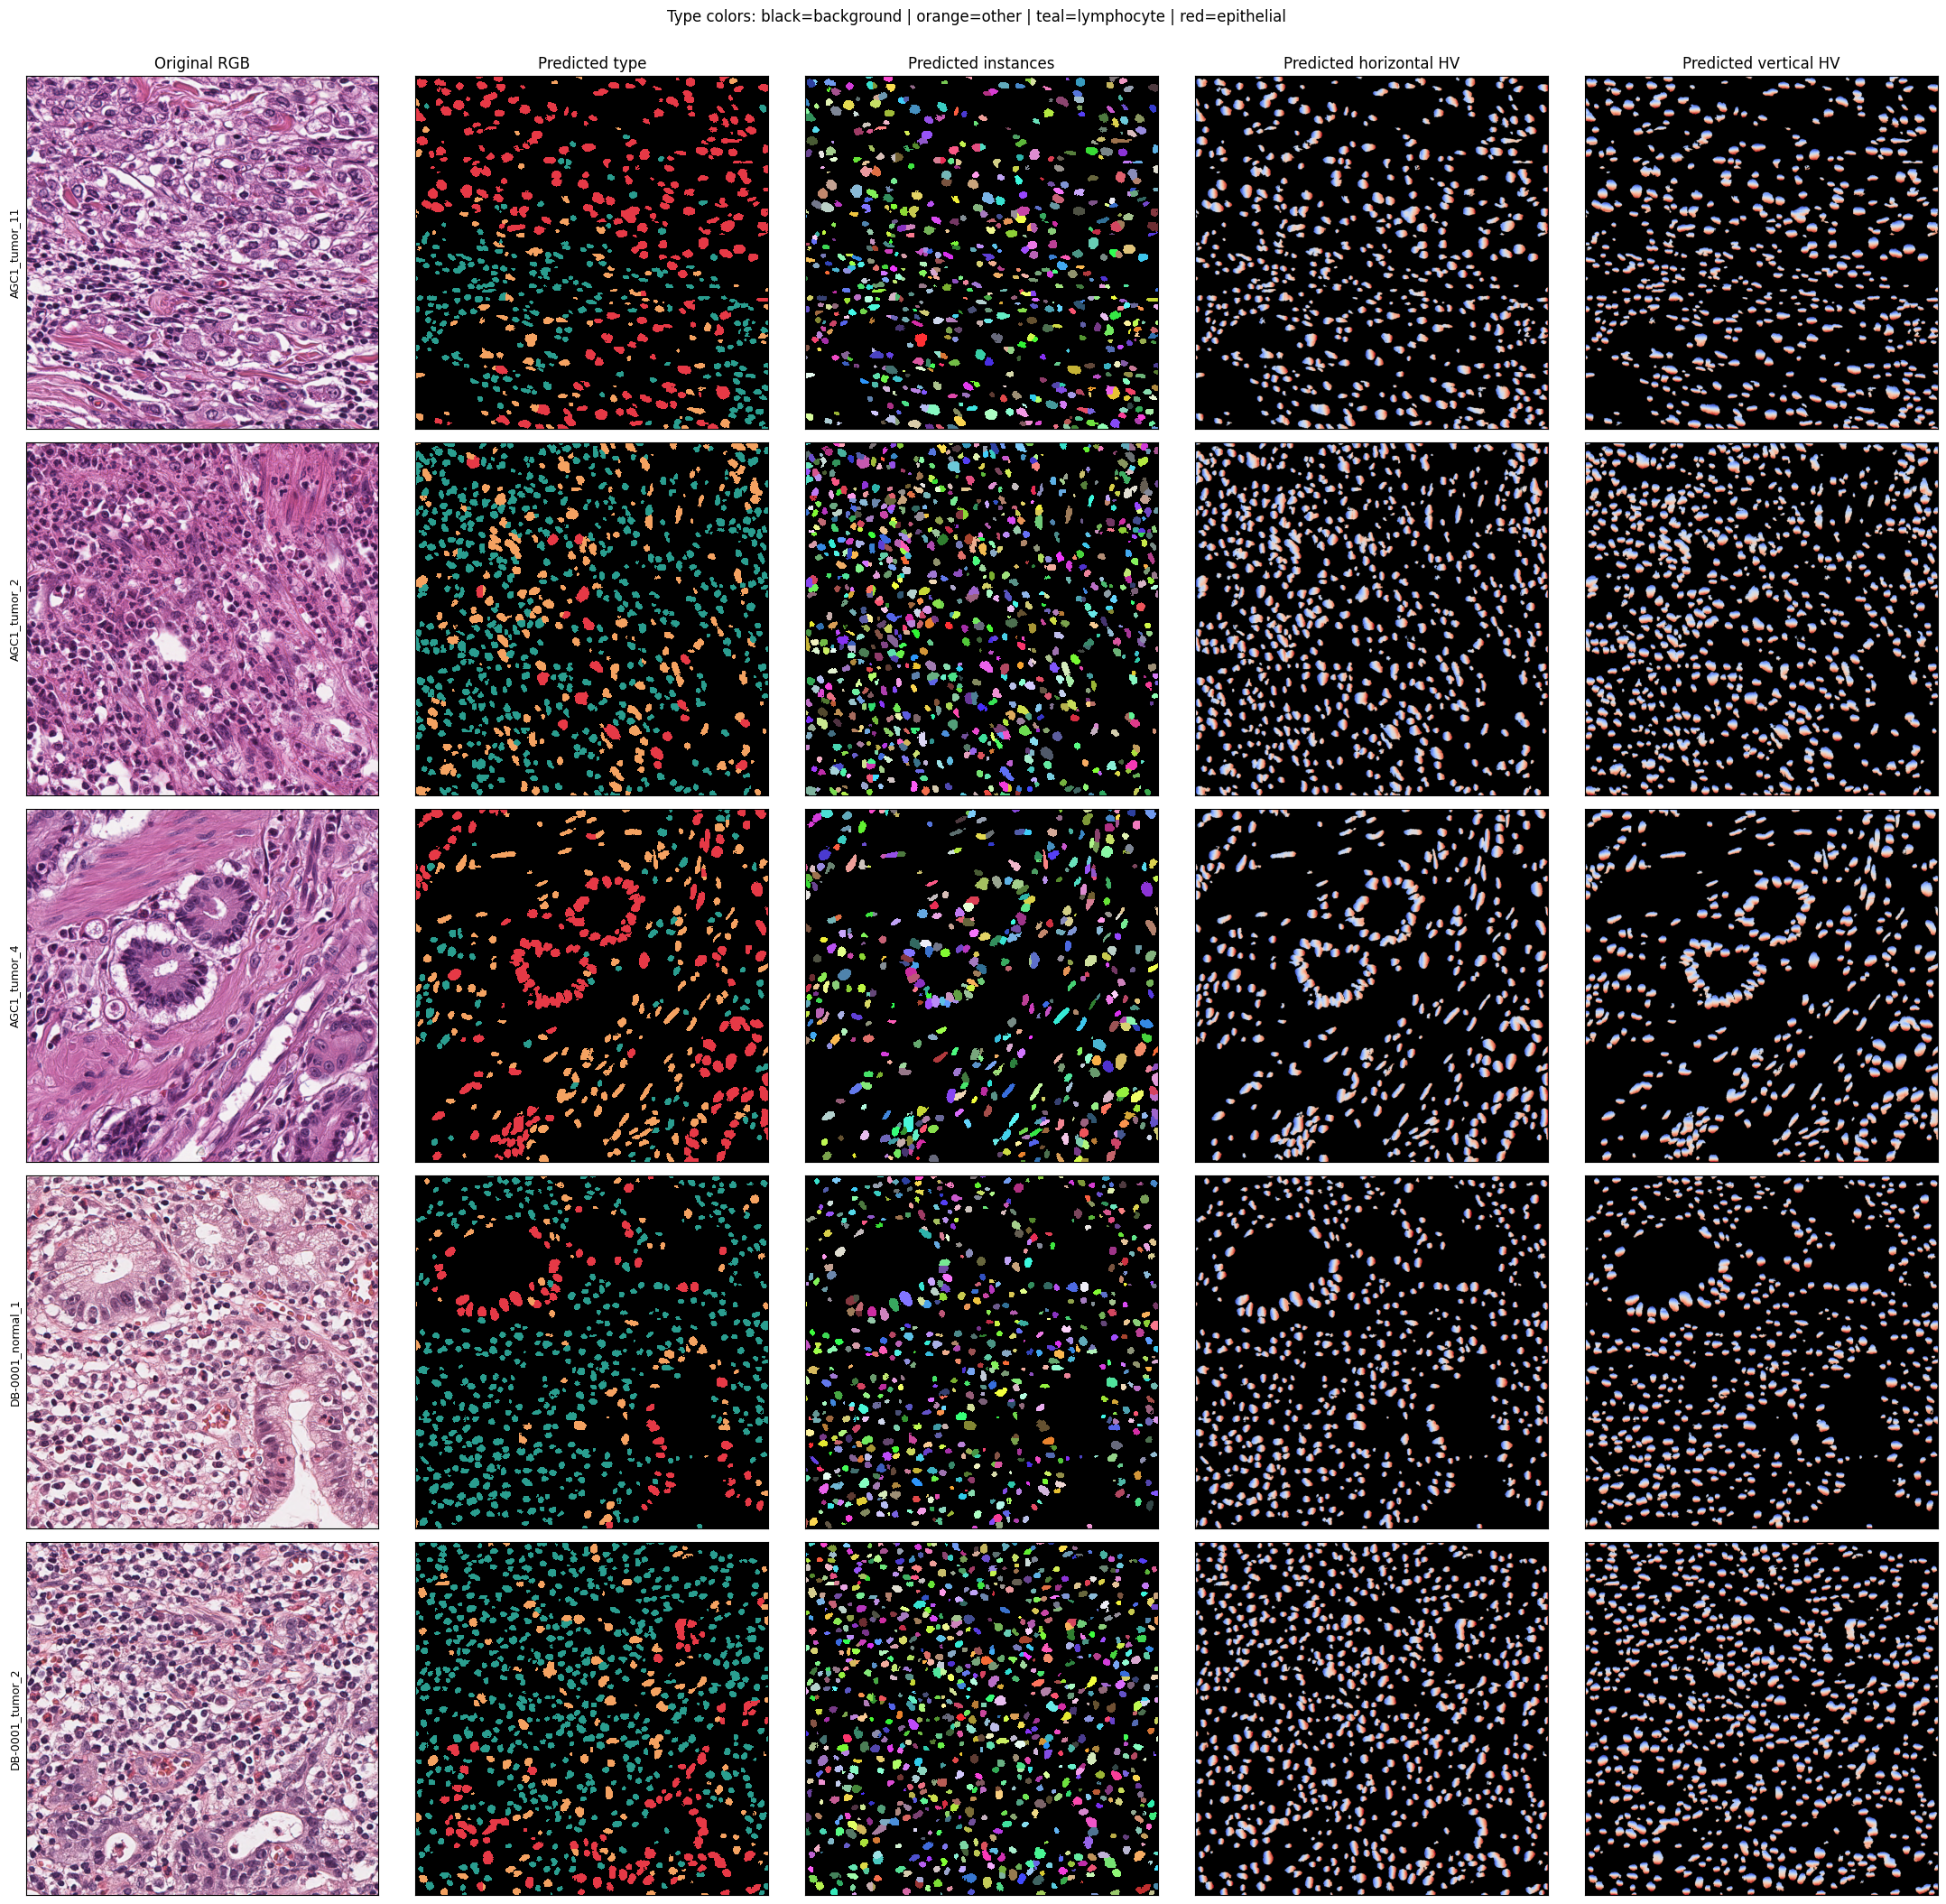

Saved visualization: /kaggle/working/mamba_unet_glysac/test_visualizations_5.png
Saved all outputs to: /kaggle/working/mamba_unet_glysac
Download artifact: /kaggle/working/mamba_unet_glysac.zip


In [12]:
TYPE_CMAP=ListedColormap(["#000000","#F4A261","#2A9D8F","#E63946"])
TYPE_NORM=BoundaryNorm([-0.5,0.5,1.5,2.5,3.5],TYPE_CMAP.N)
HV_CMAP=plt.colormaps["coolwarm"].copy(); HV_CMAP.set_bad("black")

def colored_instances(inst):
    max_id=int(inst.max()); colors=np.zeros((max_id+1,3),dtype=np.uint8)
    if max_id:
        color_rng=np.random.default_rng(CFG["SEED"])
        colors[1:]=color_rng.integers(45,256,size=(max_id,3),dtype=np.uint8)
    return colors[inst]

visual_records=test_records[:min(5,len(test_records))]
fig,axes=plt.subplots(len(visual_records),5,figsize=(22,4.2*len(visual_records)),squeeze=False)
titles=["Original RGB","Predicted type","Predicted instances","Predicted horizontal HV","Predicted vertical HV"]
for row,r in enumerate(visual_records):
    image=read_rgb(r.image)
    with np.load(OUT/"predictions_test"/f"{r.stem}.npz") as pred:
        inst=pred["inst_map"]; typ=pred["type_map"]; hv=pred["hv_map"]
    panels=[image,typ,colored_instances(inst),
            np.ma.masked_where(inst==0,np.clip(hv[...,0],-1,1)),
            np.ma.masked_where(inst==0,np.clip(hv[...,1],-1,1))]
    axes[row,0].imshow(panels[0])
    axes[row,1].imshow(panels[1],cmap=TYPE_CMAP,norm=TYPE_NORM,interpolation="nearest")
    axes[row,2].imshow(panels[2],interpolation="nearest")
    axes[row,3].imshow(panels[3],cmap=HV_CMAP,vmin=-1,vmax=1)
    axes[row,4].imshow(panels[4],cmap=HV_CMAP,vmin=-1,vmax=1)
    axes[row,0].set_ylabel(r.stem,fontsize=9)
    for col in range(5):
        if row==0: axes[row,col].set_title(titles[col])
        axes[row,col].set_xticks([]); axes[row,col].set_yticks([])
fig.suptitle("Type colors: black=background | orange=other | teal=lymphocyte | red=epithelial",y=1.002)
fig.tight_layout()
visual_path=OUT/"test_visualizations_5.png"
fig.savefig(visual_path,dpi=180,bbox_inches="tight",facecolor="white")
plt.show()
print("Saved visualization:",visual_path)

archive=shutil.make_archive(str(OUT),"zip",root_dir=OUT)
print("Saved all outputs to:",OUT)
print("Download artifact:",archive)

## Reporting checklist

For a defensible comparison, report the exact split manifest, seed, checkpoint
initialization, magnification/post-processing setting, IoU matching threshold,
and whether the number is an image mean or a global confusion-matrix score.
The closest GLySAC/SONNET-style headline numbers in this export are
`binary_dice_image_mean`, `aji_image_mean`, `binary_dq_global`,
`binary_sq_global`, `binary_pq_global`, `multiclass_dq_global`,
`multiclass_sq_global`, `multiclass_pq_global`, `centroid_det_f1_image_mean`,
and the class-wise files exported beside `metrics_test.json`.